# ASL Dynamic Sign Recognition Pipeline
**Pipeline:** Process (`asl-signs` → landmarks) → Train (Transformer + LSTM simultaneously) → Evaluate → Infer

Run cells top-to-bottom. All tunable settings are in the **Configuration** cell.

In [ ]:
import os, sys, json, math, time, platform, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

# ── Environment summary ──────────────────────────────────────────────────────
print(f'Python   : {sys.version.split()[0]}')
print(f'Platform : {platform.platform()}')
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU      : {p.name}  ({p.total_memory/1024**3:.1f} GB)')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
print(f'CPU cores: {os.cpu_count()}')

try:
    import mediapipe as mp
    print(f'MediaPipe: {mp.__version__}')
except ImportError:
    print('MediaPipe: NOT INSTALLED')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nTraining device: {DEVICE}')

## ⚙️ Configuration
Edit values here before running the rest of the notebook.

In [ ]:
# ── Sign selection ───────────────────────────────────────────────────────────
USE_ALL_SIGNS = True          # True = all 250 signs; False = CUSTOM_SIGNS
CUSTOM_SIGNS  = ['hello', 'thankyou', 'yes', 'no', 'happy']

# ── Which model to train ─────────────────────────────────────────────────────
TRAIN_MODEL = 'lstm'          # 'lstm' or 'transformer'

# ── Feature selection ────────────────────────────────────────────────────────
# Hands carry the actual sign. Default keeps a tiny curated face subset
# (lips + eyes + brows + nose) — ~40 landmarks instead of all 468.
FACE_MODE = 'key'             # 'none' | 'key' (~40 landmarks) | 'full' (all 468)
USE_POSE  = True              # 99 dims  (shoulders, arms, torso)
USE_HANDS = True              # 126 dims (LH 63 + RH 63)

# ── Paths ────────────────────────────────────────────────────────────────────
KAGGLE_DIR        = 'asl-signs'
TRAIN_CSV         = os.path.join(KAGGLE_DIR, 'train.csv')
BASE_DIR          = 'sign_language_detection'
DATA_PATH         = os.path.join(BASE_DIR, 'MP_Data')
PACKED_DATA_PATH  = os.path.join(BASE_DIR, 'Packed_Data')
PACKED_INDEX_PATH = os.path.join(BASE_DIR, 'packed_index.pt')
LOG_DIR           = os.path.join(BASE_DIR, 'Logs')
LABEL_MAP_PATH    = os.path.join(BASE_DIR, 'label_map.json')
MODEL_PATHS = {
    'transformer': os.path.join(BASE_DIR, 'my_model_transformer.pt'),
    'lstm':        os.path.join(BASE_DIR, 'my_model_lstm.pt'),
}

# ── Raw landmark layout (must match processing.py — fixed) ───────────────────
SEQUENCE_LENGTH = 30
FACE_LM, POSE_LM, HAND_LM = 468, 33, 21
FACE_DIM = FACE_LM * 3   # 1404
POSE_DIM = POSE_LM * 3   #   99
HAND_DIM = HAND_LM * 3   #   63
RAW_FEAT_DIM = FACE_DIM + POSE_DIM + HAND_DIM * 2   # 1629 (what's stored on disk)
POSE_END = FACE_DIM + POSE_DIM
LH_END   = POSE_END + HAND_DIM
RH_END   = LH_END   + HAND_DIM
EPS      = 1e-6

# ── Curated face landmarks (MediaPipe FaceMesh indices) ──────────────────────
# ~40 landmarks: lips, eye corners + lids, brows, nose, chin
FACE_KEY_LANDMARKS = [
    # lips outer + inner ring
    61, 291, 13, 14, 17, 0, 78, 308, 95, 324, 88, 318,
    87, 317, 82, 312, 81, 311, 80, 310,
    # left eye (corners + lids)
    33, 133, 159, 145,
    # right eye
    362, 263, 386, 374,
    # eyebrows
    70, 105, 107, 336, 334, 300,
    # nose
    1, 4, 168,
    # chin / jaw
    152, 175,
]

# ── Active feature slice (computed from toggles above) ───────────────────────
import numpy as _np
_active_idx = []
if FACE_MODE == 'full':
    _active_idx.append(_np.arange(0, FACE_DIM))
elif FACE_MODE == 'key':
    _face_xyz = _np.array([[3*i, 3*i+1, 3*i+2] for i in FACE_KEY_LANDMARKS]).ravel()
    _active_idx.append(_face_xyz)
elif FACE_MODE != 'none':
    raise ValueError(f"FACE_MODE must be 'none'|'key'|'full', got {FACE_MODE!r}")
if USE_POSE:  _active_idx.append(_np.arange(FACE_DIM,  POSE_END))
if USE_HANDS: _active_idx.append(_np.arange(POSE_END,  RH_END))
assert _active_idx, 'At least one feature group must be enabled.'
ACTIVE_INDICES = _np.concatenate(_active_idx).astype(_np.int64)
FEAT_DIM = int(len(ACTIVE_INDICES))   # ← what the model sees

_face_dim_active = (FEAT_DIM
                    - (POSE_DIM if USE_POSE else 0)
                    - (2*HAND_DIM if USE_HANDS else 0))

# ── Training hyperparams ─────────────────────────────────────────────────────
EPOCHS           = 80
BATCH_SIZE       = 256
GRAD_ACCUM_STEPS = 1
TEST_SPLIT       = 0.15
LEARNING_RATE    = 3e-4
WARMUP_STEPS     = 400
PATIENCE         = 20
NUM_WORKERS      = 0

# ── Augmentation (training only) ─────────────────────────────────────────────
AUG_NOISE_STD     = 0.01      # gaussian jitter on landmarks
AUG_FRAME_DROP_P  = 0.05      # prob a frame is replaced with its neighbor
AUG_TIME_SHIFT    = 2         # max +/- frame shift via roll

# ── Model hyperparams (back to ~original 4M-param scale) ─────────────────────
TRANSFORMER_CFG = dict(d_model=96,  n_heads=4, n_layers=3, d_ff=192, dropout=0.1, embedding_dim=96)
LSTM_CFG        = dict(hidden_dim=256, num_layers=3, dropout=0.2, embedding_dim=256)

# ── Processing ───────────────────────────────────────────────────────────────
MAX_SEQUENCES_PER_SIGN = None
NUM_PROC_WORKERS       = min(14, os.cpu_count() or 8)

print('Configuration loaded.')
print(f'Training model  : {TRAIN_MODEL}')
print(f'Face mode       : {FACE_MODE}   ({_face_dim_active} dims)')
print(f'Pose            : {USE_POSE}   ({POSE_DIM if USE_POSE else 0} dims)')
print(f'Hands           : {USE_HANDS}   ({2*HAND_DIM if USE_HANDS else 0} dims)')
print(f'Active FEAT_DIM : {FEAT_DIM}  (raw on disk: {RAW_FEAT_DIM})')
print(f'Sequence length : {SEQUENCE_LENGTH}')
print(f'Epochs={EPOCHS}  Batch={BATCH_SIZE}  LR={LEARNING_RATE}')


## 📋 Signs Catalog
Imports `signs.py`. Set `USE_ALL_SIGNS` in Configuration to switch between all 250 signs and a custom subset.

In [ ]:
sys.path.insert(0, '.')
from signs import SIGNS, BUNDLES, ALL_SIGNS, make_selection

ACTIONS = ALL_SIGNS if USE_ALL_SIGNS else CUSTOM_SIGNS

label = 'ALL (' + str(len(ACTIONS)) + ')' if USE_ALL_SIGNS else str(ACTIONS)
print(f'Signs selected: {label}')

## 🔧 Data Processing: `asl-signs` → Landmarks
Converts Kaggle parquet files into `.npy` keypoint sequences under `sign_language_detection/MP_Data/`.
**Resumable**: signs already present in `MP_Data/` are skipped automatically — safe to re-run after an interruption.

In [ ]:
# ── Landmark layout helpers (mirrors processing.py) ───────────────────────────
_TYPES  = ['face', 'pose', 'left_hand', 'right_hand']
_COUNTS = {'face': FACE_LM, 'pose': POSE_LM, 'left_hand': HAND_LM, 'right_hand': HAND_LM}
_print_lock = Lock()


def normalize_hand(hand_array: np.ndarray) -> np.ndarray:
    if np.all(hand_array == 0):
        return hand_array
    pts    = hand_array.reshape(HAND_LM, 3)
    center = pts[0].copy()
    pts_c  = pts - center
    scale  = np.linalg.norm(pts_c[9])
    return (pts_c / (scale if scale > EPS else 1.0)).ravel()


def _long_frame_to_keypoint(frame_df: pd.DataFrame) -> np.ndarray:
    parts = []
    for lm_type in _TYPES:
        n   = _COUNTS[lm_type]
        arr = np.zeros((n, 3), dtype=np.float32)
        sub = frame_df[frame_df['type'] == lm_type]
        if not sub.empty:
            idx   = sub['landmark_index'].values.astype(int)
            valid = (idx >= 0) & (idx < n)
            arr[idx[valid]] = np.nan_to_num(
                sub[['x', 'y', 'z']].values[valid].astype(np.float32)
            )
        parts.append(arr.ravel())
    return np.concatenate(parts)   # (1629,)


def parquet_to_keypoints(parquet_path: str) -> list[np.ndarray]:
    try:
        df = pd.read_parquet(
            parquet_path,
            columns=['frame', 'type', 'landmark_index', 'x', 'y', 'z'],
        )
    except Exception:
        return []
    df['frame'] = df['frame'].astype(int)
    frames = sorted(df['frame'].unique())
    if not frames:
        return []
    sample_idx = np.linspace(0, len(frames) - 1, SEQUENCE_LENGTH, dtype=int)
    kps: list[np.ndarray] = []
    for fid in [frames[i] for i in sample_idx]:
        kp = _long_frame_to_keypoint(df[df['frame'] == fid])
        kp[POSE_END:LH_END] = normalize_hand(kp[POSE_END:LH_END])
        kp[LH_END:RH_END]   = normalize_hand(kp[LH_END:RH_END])
        kps.append(kp)
    return kps


def _process_row(args: tuple) -> tuple[bool, str]:
    sign, seq_idx, parquet_path, sign_out = args
    kps = parquet_to_keypoints(parquet_path)
    if len(kps) != SEQUENCE_LENGTH:
        return False, f'Skipped ({len(kps)} frames): {parquet_path}'
    seq_dir = os.path.join(sign_out, str(seq_idx))
    os.makedirs(seq_dir, exist_ok=True)
    for i, kp in enumerate(kps):
        np.save(os.path.join(seq_dir, f'{i}.npy'), kp)
    return True, ''


def run_processing() -> None:
    print('\n\u2550\u2550\u2550 Data Processing \u2550\u2550\u2550\n')
    if not os.path.exists(TRAIN_CSV):
        raise FileNotFoundError(
            f'train.csv not found at \'{TRAIN_CSV}\'\n'
            f'Download the Kaggle asl-signs dataset into \'{KAGGLE_DIR}/\'.'
        )
    df_all    = pd.read_csv(TRAIN_CSV)
    available = set(df_all['sign'].unique())
    selected  = [s for s in ACTIONS if s in available]
    missing   = set(ACTIONS) - available
    if missing:
        print(f'\u26a0  Not in dataset (skipped): {missing}')
    df_all = df_all[df_all['sign'].isin(selected)]
    print(f'Processing {len(selected)} signs, {len(df_all):,} sequences total.\n')
    os.makedirs(DATA_PATH, exist_ok=True)
    total_saved = total_failed = 0
    for sign in selected:
        sign_df  = df_all[df_all['sign'] == sign]
        if MAX_SEQUENCES_PER_SIGN is not None:
            sign_df = sign_df.head(MAX_SEQUENCES_PER_SIGN)
        sign_out = os.path.join(DATA_PATH, sign)
        os.makedirs(sign_out, exist_ok=True)
        tasks = [
            (sign, i, os.path.join(KAGGLE_DIR, row['path']), sign_out)
            for i, (_, row) in enumerate(sign_df.iterrows())
        ]
        saved = failed = 0
        with ThreadPoolExecutor(max_workers=NUM_PROC_WORKERS) as ex:
            futs = {ex.submit(_process_row, t): t for t in tasks}
            with tqdm(total=len(tasks), desc=sign, leave=False) as pbar:
                for fut in as_completed(futs):
                    ok, _ = fut.result()
                    saved  += ok
                    failed += not ok
                    pbar.update(1)
        print(f'  {sign:<22} saved={saved}  skipped={failed}')
        total_saved  += saved
        total_failed += failed
    print(f'\n\u2705 Done \u2192 {DATA_PATH}')
    print(f'   Total saved: {total_saved}  |  skipped: {total_failed}')

In [ ]:
_mp_data_exists = os.path.isdir(DATA_PATH) and bool(os.listdir(DATA_PATH))
if not _mp_data_exists:
    run_processing()
else:
    print(f'\u2705 MP_Data already exists at \'{DATA_PATH}\' \u2014 skipping processing.')
    print('   Delete the folder and re-run this cell to re-process.')

## 🧠 Models
- **Transformer** (`ASLFeatureExtractor`) — imported from `asl_model.py` (unchanged)
- **LSTM** (`ASLLSTMModel`) — bidirectional LSTM with same input/output interface

In [ ]:
from asl_model import ASLFeatureExtractor


class ASLLSTMModel(nn.Module):
    """Bidirectional LSTM with mean+max+last pooling — captures the full
    signing trajectory instead of just the final hidden state."""

    def __init__(self, feat_dim: int, num_classes: int,
                 hidden_dim: int = 256, num_layers: int = 3,
                 dropout: float = 0.2, embedding_dim: int | None = None):
        super().__init__()
        self.feat_dim      = feat_dim
        self.num_classes   = num_classes
        self.hidden_dim    = hidden_dim
        self.embedding_dim = embedding_dim or hidden_dim

        self.input_proj = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        # mean + max + last → 3 × (hidden_dim * 2)
        pool_dim = hidden_dim * 2 * 3
        self.embedding_head = nn.Sequential(
            nn.Linear(pool_dim, self.embedding_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(self.embedding_dim),
        )
        self.classifier = nn.Linear(self.embedding_dim, num_classes)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        x      = self.input_proj(x)
        out, _ = self.lstm(x)                    # (B, T, 2H)
        mean_p = out.mean(dim=1)
        max_p  = out.max(dim=1).values
        last_p = out[:, -1, :]
        pooled = torch.cat([mean_p, max_p, last_p], dim=-1)
        emb    = self.embedding_head(pooled)
        return F.normalize(emb, dim=-1)

    def forward(self, x: torch.Tensor, return_embedding: bool = False) -> torch.Tensor:
        emb = self.encode(x)
        if return_embedding:
            return emb
        return self.classifier(emb)


def build_models(num_classes: int) -> dict[str, nn.Module]:
    transformer = ASLFeatureExtractor(FEAT_DIM, num_classes, **TRANSFORMER_CFG).to(DEVICE)
    lstm        = ASLLSTMModel(FEAT_DIM, num_classes, **LSTM_CFG).to(DEVICE)
    return {'transformer': transformer, 'lstm': lstm}


# Parameter count preview
_nc = len(ACTIONS)
for _name, _m in build_models(_nc).items():
    _n = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f'{_name:<15}: {_n:,} parameters')
del _nc, _name, _m, _n


## 📦 Dataset
Packs per-frame `.npy` files into single-sequence arrays for fast loading (from `train.py`).

In [ ]:
CONSOLIDATED_PATH = os.path.join(BASE_DIR, 'all_data_fp16.npy')


def ensure_normalized(kp: np.ndarray) -> np.ndarray:
    out = kp.copy()
    out[POSE_END:LH_END] = normalize_hand(kp[POSE_END:LH_END])
    out[LH_END:RH_END]   = normalize_hand(kp[LH_END:RH_END])
    return out


def _load_raw_sequence(seq_path: str) -> np.ndarray:
    seq = np.empty((SEQUENCE_LENGTH, RAW_FEAT_DIM), dtype=np.float32)
    for i in range(SEQUENCE_LENGTH):
        seq[i] = ensure_normalized(
            np.load(os.path.join(seq_path, f'{i}.npy'), allow_pickle=False)
        )
    return seq


def _pack_sequence(raw_path: str, packed_path: str) -> None:
    os.makedirs(os.path.dirname(packed_path), exist_ok=True)
    np.save(packed_path, _load_raw_sequence(raw_path))


def _build_consolidated(samples: list[tuple[str, int]]) -> None:
    n = len(samples)
    print(f'Building consolidated fp16 dataset ({n} sequences) — one-time, ~2-3 min ...')
    out = np.empty((n, SEQUENCE_LENGTH, RAW_FEAT_DIM), dtype=np.float16)
    for i, (path, _) in enumerate(tqdm(samples, desc='Consolidating')):
        out[i] = np.load(path, allow_pickle=False).astype(np.float16)
    np.save(CONSOLIDATED_PATH, out)
    print(f'✅ Saved → {CONSOLIDATED_PATH}  ({out.nbytes / 1e9:.2f} GB)')


def _augment(seq: np.ndarray) -> np.ndarray:
    """Light augmentation on an active-feature sequence (T, FEAT_DIM)."""
    if AUG_TIME_SHIFT > 0:
        s = np.random.randint(-AUG_TIME_SHIFT, AUG_TIME_SHIFT + 1)
        if s != 0:
            seq = np.roll(seq, s, axis=0)
    if AUG_FRAME_DROP_P > 0:
        mask = np.random.rand(seq.shape[0]) < AUG_FRAME_DROP_P
        for i in range(1, seq.shape[0]):
            if mask[i]:
                seq[i] = seq[i - 1]
    if AUG_NOISE_STD > 0:
        noise = np.random.randn(*seq.shape).astype(np.float32) * AUG_NOISE_STD
        seq = seq + noise * (seq != 0).astype(np.float32)
    return seq


class SignDataset(Dataset):
    """Memory-mapped fp16 dataset. Stores RAW_FEAT_DIM=1629 on disk
    and slices to ACTIVE_INDICES on the fly."""

    # Class-level default so cache-restored instances (via __new__) still have it.
    augment: bool = False

    def __init__(self, actions: list[str], data_path: str, label_map: dict[str, int]):
        self.samples: list[tuple[str, int]] = []
        for sign in actions:
            sign_path = os.path.join(data_path, sign)
            if not os.path.isdir(sign_path):
                print(f'⚠  Missing: {sign_path} — run processing first')
                continue
            seq_dirs = sorted(
                [d for d in os.listdir(sign_path) if d.isdigit()], key=int
            )
            for seq_dir in seq_dirs:
                packed = os.path.join(PACKED_DATA_PATH, sign, f'{seq_dir}.npy')
                if not os.path.exists(packed):
                    _pack_sequence(os.path.join(sign_path, seq_dir), packed)
                self.samples.append((packed, label_map[sign]))
        print(f'Dataset: {len(self.samples)} sequences across {len(actions)} signs')
        self.data = None
        self.augment = False

    def _ensure_mmap(self) -> None:
        if self.data is not None:
            return
        need_build = True
        if os.path.exists(CONSOLIDATED_PATH):
            try:
                tmp = np.load(CONSOLIDATED_PATH, mmap_mode='r')
                if tmp.shape == (len(self.samples), SEQUENCE_LENGTH, RAW_FEAT_DIM):
                    need_build = False
                else:
                    print(f'⚠  Consolidated shape mismatch ({tmp.shape}) — rebuilding')
                    del tmp
            except Exception as e:
                print(f'⚠  Consolidated read failed ({e}) — rebuilding')
        if need_build:
            if os.path.exists(CONSOLIDATED_PATH):
                os.remove(CONSOLIDATED_PATH)
            _build_consolidated(self.samples)
        self.data = np.load(CONSOLIDATED_PATH, mmap_mode='r')
        print(f'⚡ Memory-mapped fp16 dataset: {self.data.shape}  '
              f'→ active slice (T, {FEAT_DIM})')

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        if self.data is None:
            self._ensure_mmap()
        raw = np.asarray(self.data[idx], dtype=np.float32)   # (T, RAW_FEAT_DIM)
        seq = raw[:, ACTIVE_INDICES]                          # (T, FEAT_DIM)
        if self.augment:
            seq = _augment(seq)
        x = torch.from_numpy(np.ascontiguousarray(seq))
        y = torch.tensor(self.samples[idx][1], dtype=torch.long)
        return x, y


class _AugWrapper(Dataset):
    """Wraps a Subset so we can flip augmentation on for train only."""
    def __init__(self, subset, augment: bool):
        self.subset  = subset
        self.augment = augment
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        base = self.subset.dataset
        was = getattr(base, 'augment', False)
        base.augment = self.augment
        try:
            return self.subset[i]
        finally:
            base.augment = was


## 🚀 Train Model
Set `TRAIN_MODEL = 'lstm'` or `'transformer'` in the Configuration cell, then run this cell.

GPU-maximized: large batch (256), AMP fp16, fused AdamW, `torch.compile`, and cosine-warmup LR.

In [ ]:
class WarmupCosineScheduler(optim.lr_scheduler.LambdaLR):
    def __init__(self, optimizer, warmup_steps: int, total_steps: int):
        def lr_lambda(step: int) -> float:
            if step < warmup_steps:
                return step / max(1, warmup_steps)
            p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
            return max(0.0, 0.5 * (1.0 + math.cos(math.pi * p)))
        super().__init__(optimizer, lr_lambda)


def train_both_one_epoch(
    models:     dict[str, nn.Module],
    loader:     DataLoader,
    optimizers: dict[str, optim.Optimizer],
    schedulers: dict,
    criterion:  nn.Module,
    scalers:    dict,
) -> dict[str, float]:
    for m in models.values():
        m.train()
    total_losses = {n: 0.0 for n in models}
    total = 0
    for opt in optimizers.values():
        opt.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(loader, start=1):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        should_step = (step % GRAD_ACCUM_STEPS == 0) or (step == len(loader))

        for name, model in models.items():
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                                enabled=DEVICE.type == 'cuda'):
                loss = criterion(model(x), y) / GRAD_ACCUM_STEPS
            scalers[name].scale(loss).backward()
            if should_step:
                scalers[name].unscale_(optimizers[name])
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scalers[name].step(optimizers[name])
                scalers[name].update()
                optimizers[name].zero_grad(set_to_none=True)
                schedulers[name].step()
            total_losses[name] += loss.item() * x.size(0) * GRAD_ACCUM_STEPS
        total += x.size(0)

    return {n: total_losses[n] / total for n in models}


def val_both_one_epoch(
    models:    dict[str, nn.Module],
    loader:    DataLoader,
    criterion: nn.Module,
) -> dict[str, tuple[float, float]]:
    results = {}
    for name, model in models.items():
        model.eval()
        loss_sum = correct = total = 0
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits    = model(x)
                loss_sum += criterion(logits, y).item() * x.size(0)
                correct  += (logits.argmax(1) == y).sum().item()
                total    += x.size(0)
        results[name] = (loss_sum / total, correct / total)
    return results

In [ ]:
def _load_or_build_dataset(label_map: dict) -> 'SignDataset':
    if os.path.exists(PACKED_INDEX_PATH):
        cache = torch.load(PACKED_INDEX_PATH, weights_only=False)
        if cache.get('actions') == ACTIONS and cache.get('seq_len') == SEQUENCE_LENGTH:
            ds = SignDataset.__new__(SignDataset)
            ds.samples = cache['samples']
            ds.data    = None
            print(f'⚡ Loaded {len(ds)} sequences from cache')
            ds._ensure_mmap()
            return ds
        print('⚠  Cache mismatch — rebuilding ...')
    os.makedirs(PACKED_DATA_PATH, exist_ok=True)
    ds = SignDataset(ACTIONS, DATA_PATH, label_map)
    torch.save(
        {'samples': ds.samples, 'actions': ACTIONS, 'seq_len': SEQUENCE_LENGTH},
        PACKED_INDEX_PATH,
    )
    print(f'✅ Cache saved → {PACKED_INDEX_PATH}')
    ds._ensure_mmap()
    return ds


def run_training(arch: str = TRAIN_MODEL):
    assert arch in ('lstm', 'transformer'), \
        f"TRAIN_MODEL must be 'lstm' or 'transformer', got '{arch}'"

    label_map = {sign: idx for idx, sign in enumerate(ACTIONS)}
    os.makedirs(BASE_DIR, exist_ok=True)
    with open(LABEL_MAP_PATH, 'w') as f:
        json.dump(label_map, f, indent=2)
    print(f'✅ Label map saved → {LABEL_MAP_PATH}')
    print(f'🎯 Training: {arch.upper()}\n')

    # ── Dataset (mmap'd fp16, ~zero IO per batch) ────────────────────────────
    full_ds = _load_or_build_dataset(label_map)
    n_test  = max(1, int(len(full_ds) * TEST_SPLIT))
    n_train = len(full_ds) - n_test
    train_ds, test_ds = random_split(
        full_ds, [n_train, n_test],
        generator=torch.Generator().manual_seed(42),
    )
    print(f'Train: {len(train_ds)}  |  Test: {len(test_ds)}')

    pin = DEVICE.type == 'cuda'
    lkw: dict = dict(num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=False)
    if NUM_WORKERS > 0:
        lkw['prefetch_factor'] = 4
    # Wrap train split with augmentation enabled, test stays clean
    train_ds = _AugWrapper(train_ds, augment=True)
    test_ds  = _AugWrapper(test_ds,  augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,     shuffle=True,  **lkw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2, shuffle=False, **lkw)

    # ── Model ────────────────────────────────────────────────────────────────
    if arch == 'transformer':
        model = ASLFeatureExtractor(FEAT_DIM, len(ACTIONS), **TRANSFORMER_CFG).to(DEVICE)
    else:
        model = ASLLSTMModel(FEAT_DIM, len(ACTIONS), **LSTM_CFG).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{arch:<15}: {n_params:,} parameters')

    # ── Optimizer / scheduler / scaler ───────────────────────────────────────
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    try:
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                weight_decay=1e-4, fused=True)
        print('AdamW          : fused=True')
    except TypeError:
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        print('AdamW          : standard')

    scaler  = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
    steps_per_epoch = math.ceil(len(train_loader) / max(GRAD_ACCUM_STEPS, 1))
    total_steps     = steps_per_epoch * EPOCHS
    scheduler       = WarmupCosineScheduler(optimizer, WARMUP_STEPS, total_steps)

    print(f'Steps/epoch    : {steps_per_epoch}  |  Total steps: {total_steps}')
    print(f'LR             : {LEARNING_RATE}  |  Batch: {BATCH_SIZE}\n')

    best_val_acc = 0.0
    no_improve   = 0
    log_rows: list[dict] = []
    t0_total = time.time()

    print(f'🚀 Training {arch.upper()} ...\n')

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        optimizer.zero_grad(set_to_none=True)

        for step, (x, y) in enumerate(train_loader, start=1):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                                enabled=DEVICE.type == 'cuda'):
                loss = criterion(model(x), y)
                if GRAD_ACCUM_STEPS > 1:
                    loss = loss / GRAD_ACCUM_STEPS
            scaler.scale(loss).backward()
            if step % max(GRAD_ACCUM_STEPS, 1) == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
            train_loss += loss.item() * x.size(0) * max(GRAD_ACCUM_STEPS, 1)
        train_loss /= len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_loss = correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                                    enabled=DEVICE.type == 'cuda'):
                    logits = model(x)
                val_loss += criterion(logits, y).item() * x.size(0)
                correct  += (logits.argmax(1) == y).sum().item()
                total    += x.size(0)
        val_loss /= total
        val_acc   = correct / total
        elapsed   = time.time() - t0

        # ── Checkpoint ────────────────────────────────────────────────────
        saved_marker = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            ckpt = {
                'epoch': epoch, 'model_state': model.state_dict(),
                'val_acc': val_acc, 'actions': ACTIONS, 'label_map': label_map,
                'feat_dim': FEAT_DIM, 'seq_len': SEQUENCE_LENGTH, 'arch': arch,
            }
            ckpt.update(TRANSFORMER_CFG if arch == 'transformer' else LSTM_CFG)
            torch.save(ckpt, MODEL_PATHS[arch])
            saved_marker = f'  💾 best={best_val_acc:.4f}'
        else:
            no_improve += 1

        lr_now  = optimizer.param_groups[0]['lr']
        total_h = (time.time() - t0_total) / 3600
        print(
            f'  Epoch {epoch:3d}/{EPOCHS}  [{elapsed:4.1f}s]  '
            f'lr={lr_now:.2e}  tl={train_loss:.4f}  vl={val_loss:.4f}  '
            f'acc={val_acc:.4f}  total={total_h:.2f}h{saved_marker}'
        )
        log_rows.append({
            'epoch': epoch, 'train_loss': train_loss,
            'val_loss': val_loss, 'val_acc': val_acc, 'epoch_time_s': elapsed,
        })

        if no_improve >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch} (patience={PATIENCE}).')
            break

    # ── Save log ──────────────────────────────────────────────────────────────
    os.makedirs(LOG_DIR, exist_ok=True)
    log_path = os.path.join(LOG_DIR, f'{arch}_training_log.csv')
    pd.DataFrame(log_rows).to_csv(log_path, index=False)
    total_h = (time.time() - t0_total) / 3600
    print(f'\n📋 Log → {log_path}')
    print(f'Best val accuracy : {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)')
    print(f'Total time        : {total_h:.2f}h')
    print(f'Checkpoint        → {MODEL_PATHS[arch]}')

    return model, test_loader, label_map

### Train LSTM

In [ ]:
_lstm_model, _lstm_test_loader, _label_map = run_training('lstm')

### Train Transformer

In [ ]:
_transformer_model, _transformer_test_loader, _label_map = run_training('transformer')

## 📊 Research Metrics
Loads the best checkpoint for each model and computes:
Accuracy · Precision · Recall · F1 (macro & weighted) · Per-class report

In [19]:
def compute_research_metrics(
    models:      dict[str, nn.Module],
    loader:      DataLoader,
    label_map:   dict[str, int],
    model_paths: dict[str, str],
) -> None:
    id2label    = {v: k for k, v in label_map.items()}
    class_names = [id2label[i] for i in range(len(label_map))]

    for name, model in models.items():
        ckpt_path = model_paths[name]
        if not os.path.exists(ckpt_path):
            print(f'\u26a0  No checkpoint for {name} at {ckpt_path}')
            continue
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        model.eval()

        y_true: list[int] = []
        y_pred: list[int] = []
        with torch.no_grad():
            for x, y in loader:
                preds = model(x.to(DEVICE)).argmax(1).cpu().tolist()
                y_true.extend(y.tolist())
                y_pred.extend(preds)

        acc      = accuracy_score(y_true, y_pred)
        prec_mac = precision_score(y_true, y_pred, average='macro',    zero_division=0)
        prec_wt  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec_mac  = recall_score(y_true,    y_pred, average='macro',    zero_division=0)
        rec_wt   = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
        f1_mac   = f1_score(y_true,        y_pred, average='macro',    zero_division=0)
        f1_wt    = f1_score(y_true,        y_pred, average='weighted', zero_division=0)

        sep = '\u2550' * 62
        print(f'\n{sep}')
        print(f'  Model : {name.upper()}  (epoch {ckpt.get("epoch", "?")})')
        print(sep)
        print(f'  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)')
        print(f'  Precision (macro)     : {prec_mac:.4f}')
        print(f'  Precision (weighted)  : {prec_wt:.4f}')
        print(f'  Recall    (macro)     : {rec_mac:.4f}')
        print(f'  Recall    (weighted)  : {rec_wt:.4f}')
        print(f'  F1-score  (macro)     : {f1_mac:.4f}')
        print(f'  F1-score  (weighted)  : {f1_wt:.4f}')

        report = classification_report(
            y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True
        )
        per_class = [
            (cls, report[cls])
            for cls in class_names
            if cls in report
        ]
        per_class.sort(key=lambda t: t[1]['f1-score'], reverse=True)

        print(f'\n  Per-class (top 10 + bottom 5 by F1):')
        print(f'  {"Class":<22} {"F1":>6}  {"Prec":>6}  {"Rec":>6}  {"N":>5}')
        print(f'  {"-"*48}')
        show = per_class[:10] + per_class[-5:] if len(per_class) > 15 else per_class
        prev_end = False
        for i, (cls, r) in enumerate(per_class):
            if len(per_class) > 15 and i == 10:
                print(f'  ... ({len(per_class)-15} more) ...')
            if len(per_class) <= 15 or i < 10 or i >= len(per_class) - 5:
                print(
                    f'  {cls:<22} {r["f1-score"]:>6.4f}'
                    f'  {r["precision"]:>6.4f}  {r["recall"]:>6.4f}'
                    f'  {r["support"]:>5.0f}'
                )
        print(sep)


_models_to_eval = build_models(len(ACTIONS))
compute_research_metrics(_models_to_eval, _lstm_test_loader, _label_map, MODEL_PATHS)


══════════════════════════════════════════════════════════════
  Model : TRANSFORMER  (epoch 74)
══════════════════════════════════════════════════════════════
  Accuracy              : 0.6112  (61.12%)
  Precision (macro)     : 0.6062
  Precision (weighted)  : 0.6127
  Recall    (macro)     : 0.6088
  Recall    (weighted)  : 0.6112
  F1-score  (macro)     : 0.5924
  F1-score  (weighted)  : 0.5966

  Per-class (top 10 + bottom 5 by F1):
  Class                      F1    Prec     Rec      N
  ------------------------------------------------
  horse                  0.8889  0.8814  0.8966     58
  if                     0.8780  0.8852  0.8710     62
  airplane               0.8772  0.8197  0.9434     53
  gum                    0.8739  0.8387  0.9123     57
  water                  0.8739  0.8000  0.9630     54
  uncle                  0.8593  0.7733  0.9667     60
  bug                    0.8455  0.8000  0.8966     58
  shhh                   0.8444  0.7600  0.9500     60
  donkey    

## 🔍 Inference
Loads the best checkpoint and runs inference on random test-set samples.

> **Real-time webcam/video inference:** use the standalone scripts directly:
> ```
> python infer_single_threaded.py --webcam
> python infer_single_threaded.py --input your_video.mp4
> ```

In [ ]:
def load_model_from_checkpoint(ckpt_path: str) -> tuple:
    ckpt    = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    arch    = ckpt.get('arch', 'transformer')
    actions = ckpt['actions']
    feat_dim_ckpt = ckpt.get('feat_dim', FEAT_DIM)
    if arch == 'transformer' or 'd_model' in ckpt:
        model = ASLFeatureExtractor(
            feat_dim_ckpt, len(actions),
            d_model=ckpt.get('d_model', TRANSFORMER_CFG['d_model']),
            n_heads=ckpt.get('n_heads', TRANSFORMER_CFG['n_heads']),
            n_layers=ckpt.get('n_layers', TRANSFORMER_CFG['n_layers']),
            d_ff=ckpt.get('d_ff', TRANSFORMER_CFG['d_ff']),
            dropout=ckpt.get('dropout', TRANSFORMER_CFG['dropout']),
            embedding_dim=ckpt.get('embedding_dim', TRANSFORMER_CFG['embedding_dim']),
        ).to(DEVICE)
    else:
        model = ASLLSTMModel(
            feat_dim_ckpt, len(actions),
            hidden_dim=ckpt.get('hidden_dim', LSTM_CFG['hidden_dim']),
            num_layers=ckpt.get('num_layers', LSTM_CFG['num_layers']),
            dropout=ckpt.get('dropout', LSTM_CFG['dropout']),
            embedding_dim=ckpt.get('embedding_dim', LSTM_CFG['embedding_dim']),
        ).to(DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    return model, ckpt


def _resolve_samples(ds):
    """Walks AugWrapper / Subset / SignDataset to find the (path, label) list."""
    while True:
        if hasattr(ds, 'samples'):
            return ds.samples
        if hasattr(ds, 'subset'):
            ds = ds.subset
        elif hasattr(ds, 'dataset'):
            ds = ds.dataset
        else:
            raise AttributeError('cannot find .samples on dataset chain')


def infer_test_samples(model_name: str = TRAIN_MODEL, num_samples: int = 15) -> None:
    ckpt_path = MODEL_PATHS[model_name]
    if not os.path.exists(ckpt_path):
        print(f'No checkpoint at {ckpt_path}. Run training first.')
        return

    model, ckpt = load_model_from_checkpoint(ckpt_path)
    id2label    = {v: k for k, v in ckpt['label_map'].items()}
    softmax     = nn.Softmax(dim=1)

    all_samples = _resolve_samples(_lstm_test_loader.dataset)
    samples     = random.sample(all_samples, min(num_samples, len(all_samples)))

    print(f'\n🔍 Inference  ({model_name})  |  {len(ckpt["actions"])} classes\n')
    print(f'  {"#":<4}  {"True label":<22}  {"Predicted":<22}  {"Conf":>6}  OK?')
    print(f'  {"-"*64}')

    correct = 0
    for i, (packed_path, true_label) in enumerate(samples):
        raw = np.load(packed_path, allow_pickle=False)[:, ACTIVE_INDICES]
        x   = torch.from_numpy(np.ascontiguousarray(raw)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs     = softmax(model(x))[0].cpu().numpy()
        pred_idx  = int(np.argmax(probs))
        conf      = float(probs[pred_idx])
        pred_name = id2label[pred_idx]
        true_name = id2label[true_label]
        ok        = pred_idx == true_label
        correct  += ok
        mark      = '✅' if ok else '✗ '
        print(f'  {i+1:<4}  {true_name:<22}  {pred_name:<22}  {conf:>6.2%}  {mark}')

    print(f'\n  Accuracy on {len(samples)} samples: {correct}/{len(samples)} = {correct/len(samples):.2%}')


infer_test_samples(model_name='lstm', num_samples=5)
infer_test_samples(model_name='transformer', num_samples=5)


## 🆚 Model Comparison
Predicts every test sample with **every** trained checkpoint and produces:
- per-model accuracy / macro-F1 / avg confidence summary table
- pairwise agreement (both correct, only A correct, only B correct, both wrong)
- **oracle ceiling** (upper bound if we always picked whichever model was right)
- bottom-15 hardest signs and top-10 easiest signs (per-class accuracy across models)
- saved CSVs: `model_comparison_summary.csv`, `<model>_predictions.csv` (full per-sample predictions)

Stores everything in `_eval_results` so the plot cells below can reuse it without re-running inference.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix


def _evaluate_full(model: nn.Module, loader: DataLoader) -> tuple:
    """Run model on full loader; return (y_true, y_pred, conf) numpy arrays."""
    model.eval()
    ys, ps, cs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x      = x.to(DEVICE, non_blocking=True)
            logits = model(x)
            probs  = F.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
            ys.append(y.numpy())
            ps.append(pred.cpu().numpy())
            cs.append(conf.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(cs)


def run_model_comparison() -> dict:
    """Predict every test sample with every available model, then summarize."""
    id2label = {v: k for k, v in _label_map.items()}
    n_classes = len(_label_map)

    results: dict = {}
    for name, ckpt_path in MODEL_PATHS.items():
        if not os.path.exists(ckpt_path):
            print(f'⚠  No checkpoint for {name} at {ckpt_path}  —  skipping')
            continue
        print(f'⏳ Evaluating {name} ...')
        model, ckpt = load_model_from_checkpoint(ckpt_path)
        y_true, y_pred, conf = _evaluate_full(model, _lstm_test_loader)
        results[name] = {
            'y_true': y_true, 'y_pred': y_pred, 'conf': conf,
            'epoch':  ckpt.get('epoch', -1),
            'params': sum(p.numel() for p in model.parameters() if p.requires_grad),
        }
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if not results:
        print('No models to compare.')
        return results

    # ── Summary table ────────────────────────────────────────────────────────
    sep = '═' * 92
    print(f'\n{sep}')
    print(f'  📊 MODEL COMPARISON  —  evaluated on {len(next(iter(results.values()))["y_true"])} test samples')
    print(sep)
    header = f'  {"Model":<14}{"Epoch":>7}{"Params":>12}{"Total":>8}{"Correct":>10}{"Wrong":>8}{"Acc":>9}{"Macro-F1":>11}{"AvgConf":>10}'
    print(header)
    print('-' * len(header))
    summary_rows = []
    for name, r in results.items():
        n   = len(r['y_true'])
        ok  = int((r['y_pred'] == r['y_true']).sum())
        acc = ok / n
        f1m = f1_score(r['y_true'], r['y_pred'],
                       labels=list(range(n_classes)), average='macro', zero_division=0)
        cm  = float(r['conf'].mean())
        print(f'  {name:<14}{r["epoch"]:>7}{r["params"]:>12,}{n:>8}{ok:>10}{n-ok:>8}'
              f'{acc:>9.4f}{f1m:>11.4f}{cm:>10.4f}')
        summary_rows.append({
            'model': name, 'epoch': r['epoch'], 'params': r['params'],
            'total': n, 'correct': ok, 'wrong': n - ok,
            'accuracy': acc, 'macro_f1': f1m, 'avg_confidence': cm,
        })
    print(sep)

    # ── Pairwise agreement (only if exactly 2 models present) ────────────────
    if len(results) == 2:
        names = list(results.keys())
        a, b  = results[names[0]], results[names[1]]
        a_ok  = a['y_pred'] == a['y_true']
        b_ok  = b['y_pred'] == b['y_true']
        agree = (a['y_pred'] == b['y_pred']).mean()
        both_ok    = int((a_ok &  b_ok).sum())
        only_a     = int((a_ok & ~b_ok).sum())
        only_b     = int((~a_ok &  b_ok).sum())
        both_wrong = int((~a_ok & ~b_ok).sum())
        print(f'\n  🤝 Pairwise agreement: {agree:.4f}  ({names[0]} vs {names[1]})')
        print(f'     Both correct      : {both_ok:>6}')
        print(f'     Only {names[0]:<14}: {only_a:>6}')
        print(f'     Only {names[1]:<14}: {only_b:>6}')
        print(f'     Both wrong        : {both_wrong:>6}')
        print(f'     Oracle ceiling    : {(both_ok + only_a + only_b)/len(a["y_true"]):.4f}'
              '  (if we always picked whichever model was right)')

    # ── Hardest classes (lowest min per-class accuracy across models) ────────
    print(f'\n  🔻 Bottom-15 hardest signs (per-class accuracy):')
    head = f'  {"Sign":<22}'
    for n in results: head += f'{n:>14}'
    head += f'{"Worst":>10}'
    print(head)
    print('  ' + '-' * (len(head) - 2))
    rows = []
    for c in range(n_classes):
        accs = []
        for r in results.values():
            mask = r['y_true'] == c
            accs.append(float((r['y_pred'][mask] == c).mean()) if mask.sum() else 0.0)
        rows.append((c, accs))
    rows.sort(key=lambda x: min(x[1]))
    for c, accs in rows[:15]:
        line = f'  {id2label[c]:<22}'
        for a in accs: line += f'{a:>14.4f}'
        line += f'{min(accs):>10.4f}'
        print(line)

    # ── Easiest classes ──────────────────────────────────────────────────────
    print(f'\n  🟢 Top-10 easiest signs:')
    print(head)
    print('  ' + '-' * (len(head) - 2))
    for c, accs in sorted(rows, key=lambda x: -min(x[1]))[:10]:
        line = f'  {id2label[c]:<22}'
        for a in accs: line += f'{a:>14.4f}'
        line += f'{min(accs):>10.4f}'
        print(line)

    # ── Save artifacts ───────────────────────────────────────────────────────
    os.makedirs(LOG_DIR, exist_ok=True)
    summary_path = os.path.join(LOG_DIR, 'model_comparison_summary.csv')
    pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
    print(f'\n  💾 Summary CSV  → {summary_path}')

    # full predictions per model
    for name, r in results.items():
        df = pd.DataFrame({
            'true_id'   : r['y_true'],
            'true_label': [id2label[i] for i in r['y_true']],
            'pred_id'   : r['y_pred'],
            'pred_label': [id2label[i] for i in r['y_pred']],
            'confidence': r['conf'],
            'correct'   : (r['y_pred'] == r['y_true']),
        })
        out = os.path.join(LOG_DIR, f'{name}_predictions.csv')
        df.to_csv(out, index=False)
        print(f'  💾 {name} predictions → {out}')

    return results


def _make_research_plots(model_name: str, results: dict,
                         label_map: dict, save_dir: str) -> None:
    """4-panel research figure for a single model."""
    if model_name not in results:
        print(f'⚠  No results for {model_name}'); return
    r        = results[model_name]
    y_true   = r['y_true']
    y_pred   = r['y_pred']
    conf     = r['conf']
    id2label = {v: k for k, v in label_map.items()}
    classes  = [id2label[i] for i in range(len(label_map))]
    correct  = (y_pred == y_true)
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(16, 13))

    # ── (1) Per-class F1: top-20 vs bottom-20 ────────────────────────────────
    f1 = f1_score(y_true, y_pred,
                  labels=list(range(len(classes))),
                  average=None, zero_division=0)
    order  = np.argsort(f1)
    bottom = order[:20]
    top    = order[-20:][::-1]
    sel    = np.concatenate([top, bottom])
    colors = ['#2ca02c'] * 20 + ['#d62728'] * 20
    ax = axes[0, 0]
    ax.barh(range(40), f1[sel], color=colors)
    ax.set_yticks(range(40))
    ax.set_yticklabels([classes[i] for i in sel], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.axvline(f1.mean(), color='black', linestyle='--',
               label=f'macro mean = {f1.mean():.3f}')
    ax.set_xlabel('F1 score')
    ax.set_title(f'{model_name.upper()}  —  Top 20 (green) vs Bottom 20 (red) classes')
    ax.legend(loc='lower right')

    # ── (2) Confidence distribution: correct vs incorrect ────────────────────
    ax = axes[0, 1]
    bins = np.linspace(0, 1, 26)
    ax.hist(conf[correct],  bins=bins, alpha=0.65,
            label=f'correct   (n={correct.sum()})',   color='#2ca02c')
    ax.hist(conf[~correct], bins=bins, alpha=0.65,
            label=f'incorrect (n={(~correct).sum()})', color='#d62728')
    ax.set_xlabel('Top-1 predicted probability')
    ax.set_ylabel('# samples')
    ax.set_title(f'{model_name.upper()}  —  Confidence distribution')
    ax.legend()

    # ── (3) Top-30 most-confused submatrix (row-normalized) ──────────────────
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    err = cm.copy(); np.fill_diagonal(err, 0)
    err_score = err.sum(axis=1) + err.sum(axis=0)   # confusion in + out
    top30 = np.argsort(err_score)[-30:][::-1]
    sub   = cm[np.ix_(top30, top30)].astype(np.float32)
    sub_n = sub / np.maximum(sub.sum(axis=1, keepdims=True), 1)
    ax = axes[1, 0]
    im = ax.imshow(sub_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(30)); ax.set_yticks(range(30))
    ax.set_xticklabels([classes[i] for i in top30], rotation=90, fontsize=6)
    ax.set_yticklabels([classes[i] for i in top30], fontsize=6)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name.upper()}  —  Confusion (top 30 noisiest classes, row-normalized)')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # ── (4) Calibration curve (reliability diagram) ──────────────────────────
    ax = axes[1, 1]
    edges = np.linspace(0, 1, 11)
    accs, confs, ns = [], [], []
    for i in range(10):
        if i < 9: mask = (conf >= edges[i]) & (conf <  edges[i + 1])
        else:     mask = (conf >= edges[i]) & (conf <= edges[i + 1])
        if mask.sum() == 0:
            accs.append(np.nan); confs.append((edges[i] + edges[i + 1]) / 2); ns.append(0); continue
        accs.append(correct[mask].mean())
        confs.append(conf[mask].mean())
        ns.append(int(mask.sum()))
    ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect calibration')
    ax.plot(confs, accs, 'o-', color='#1f77b4', markersize=8, label=f'{model_name}')
    for c, a, n in zip(confs, accs, ns):
        if n > 0:
            ax.annotate(f'n={n}', (c, a), fontsize=7,
                        xytext=(4, -10), textcoords='offset points')
    # ECE
    valid = [(a, c, n) for a, c, n in zip(accs, confs, ns) if n > 0]
    total = sum(n for _, _, n in valid)
    ece = sum(n / total * abs(a - c) for a, c, n in valid) if total else 0.0
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{model_name.upper()}  —  Reliability  (ECE = {ece:.4f})')
    ax.legend(loc='upper left')

    plt.suptitle(f'Research diagnostics — {model_name.upper()}',
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    out = os.path.join(save_dir, f'{model_name}_research_plots.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {out}')


_eval_results = run_model_comparison()


⏳ Evaluating transformer ...
⏳ Evaluating lstm ...

════════════════════════════════════════════════════════════════════════════════════════════
  📊 MODEL COMPARISON  —  evaluated on 14171 test samples
════════════════════════════════════════════════════════════════════════════════════════════
  Model           Epoch      Params   Total   Correct   Wrong      Acc   Macro-F1   AvgConf
-------------------------------------------------------------------------------------------
  transformer        74     291,418   14171      8661    5510   0.6112     0.5924    0.3536
  lstm               75   4,753,146   14171     10221    3950   0.7213     0.7177    0.7789
════════════════════════════════════════════════════════════════════════════════════════════

  🤝 Pairwise agreement: 0.6247  (transformer vs lstm)
     Both correct      :   7789
     Only transformer   :    872
     Only lstm          :   2432
     Both wrong        :   3078
     Oracle ceiling    : 0.7828  (if we always picked which

### 📊 LSTM — Research Plots
A 4-panel figure replacing the unreadable 250×250 confusion matrix:
1. **Top-20 vs Bottom-20 classes by F1** — which signs are easy / hard
2. **Confidence distribution** — split by correct vs incorrect predictions
3. **Top-30 most-confused submatrix** — only the noisiest classes (row-normalized)
4. **Calibration curve** — does confidence match actual accuracy?


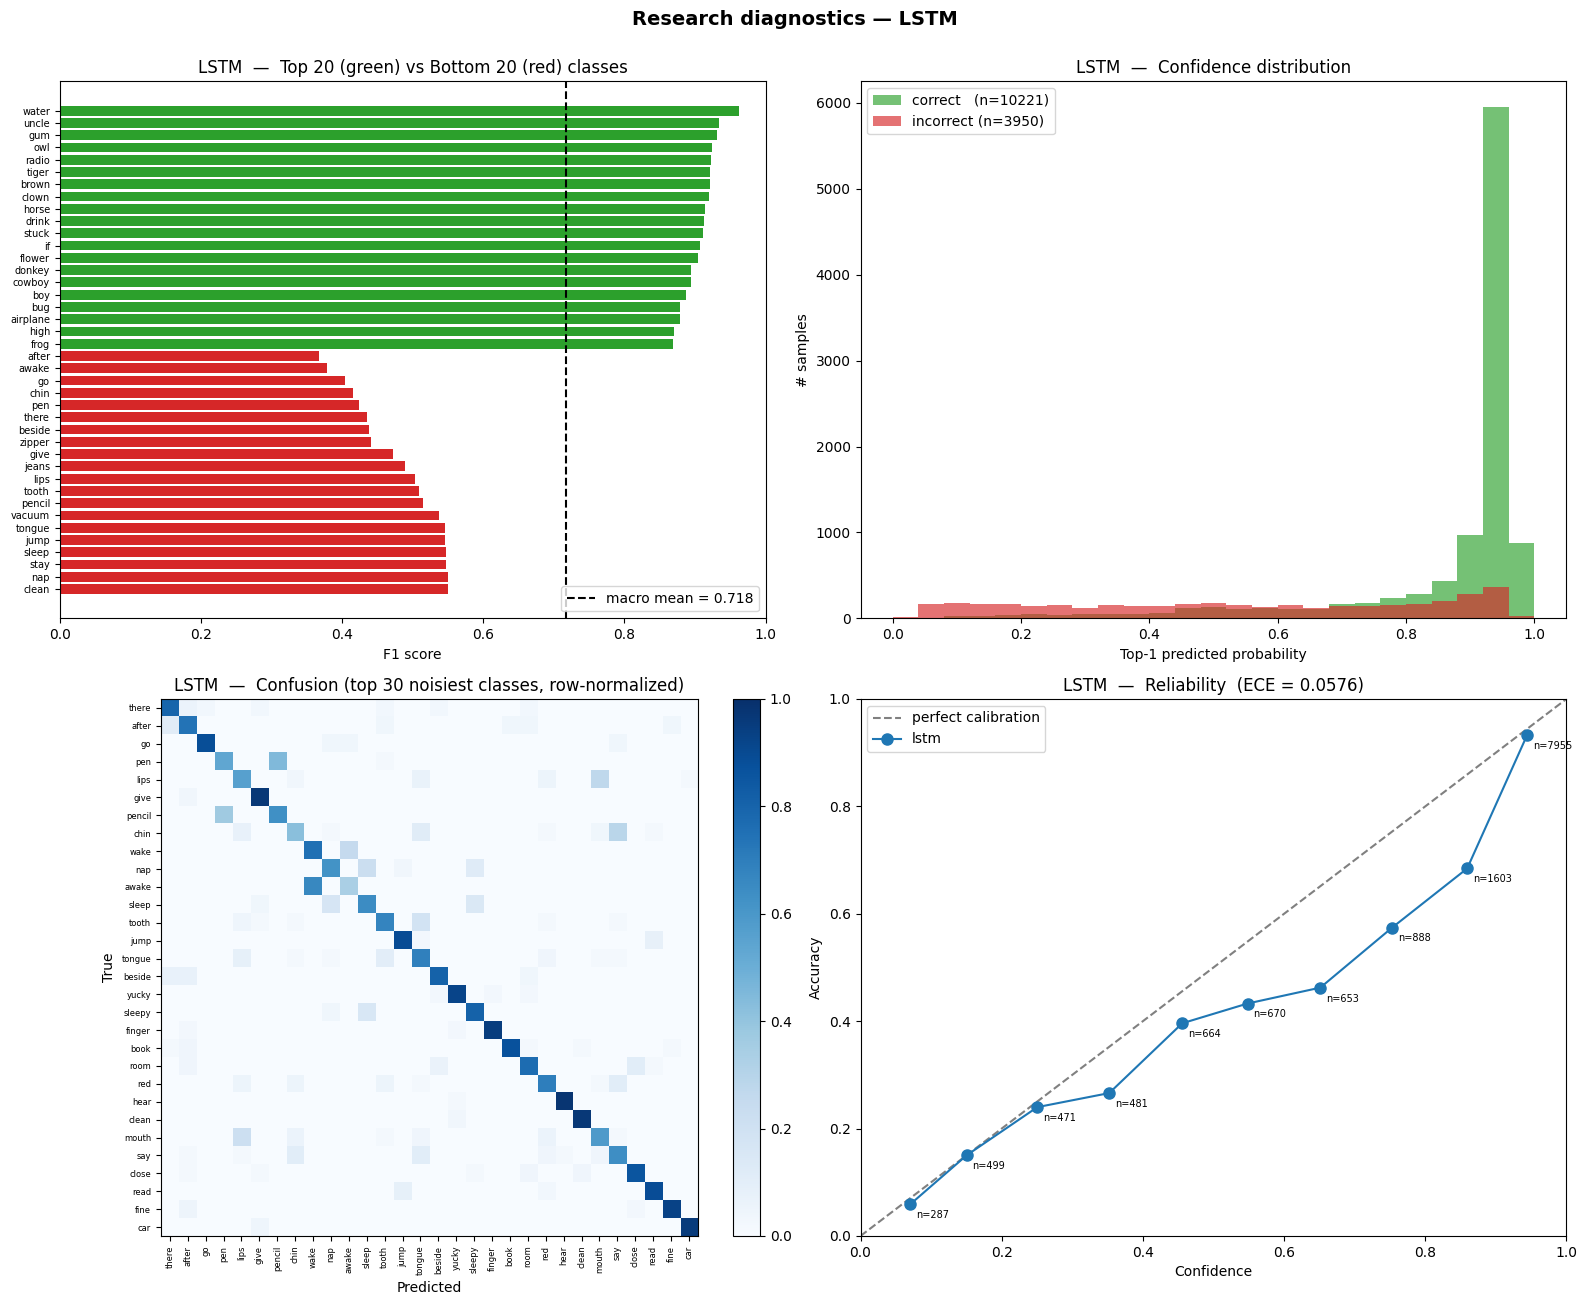

✅ Saved → sign_language_detection\Logs\lstm_research_plots.png


In [21]:
# LSTM research plots
_make_research_plots('lstm', _eval_results, _label_map, LOG_DIR)


### 📊 Transformer — Research Plots


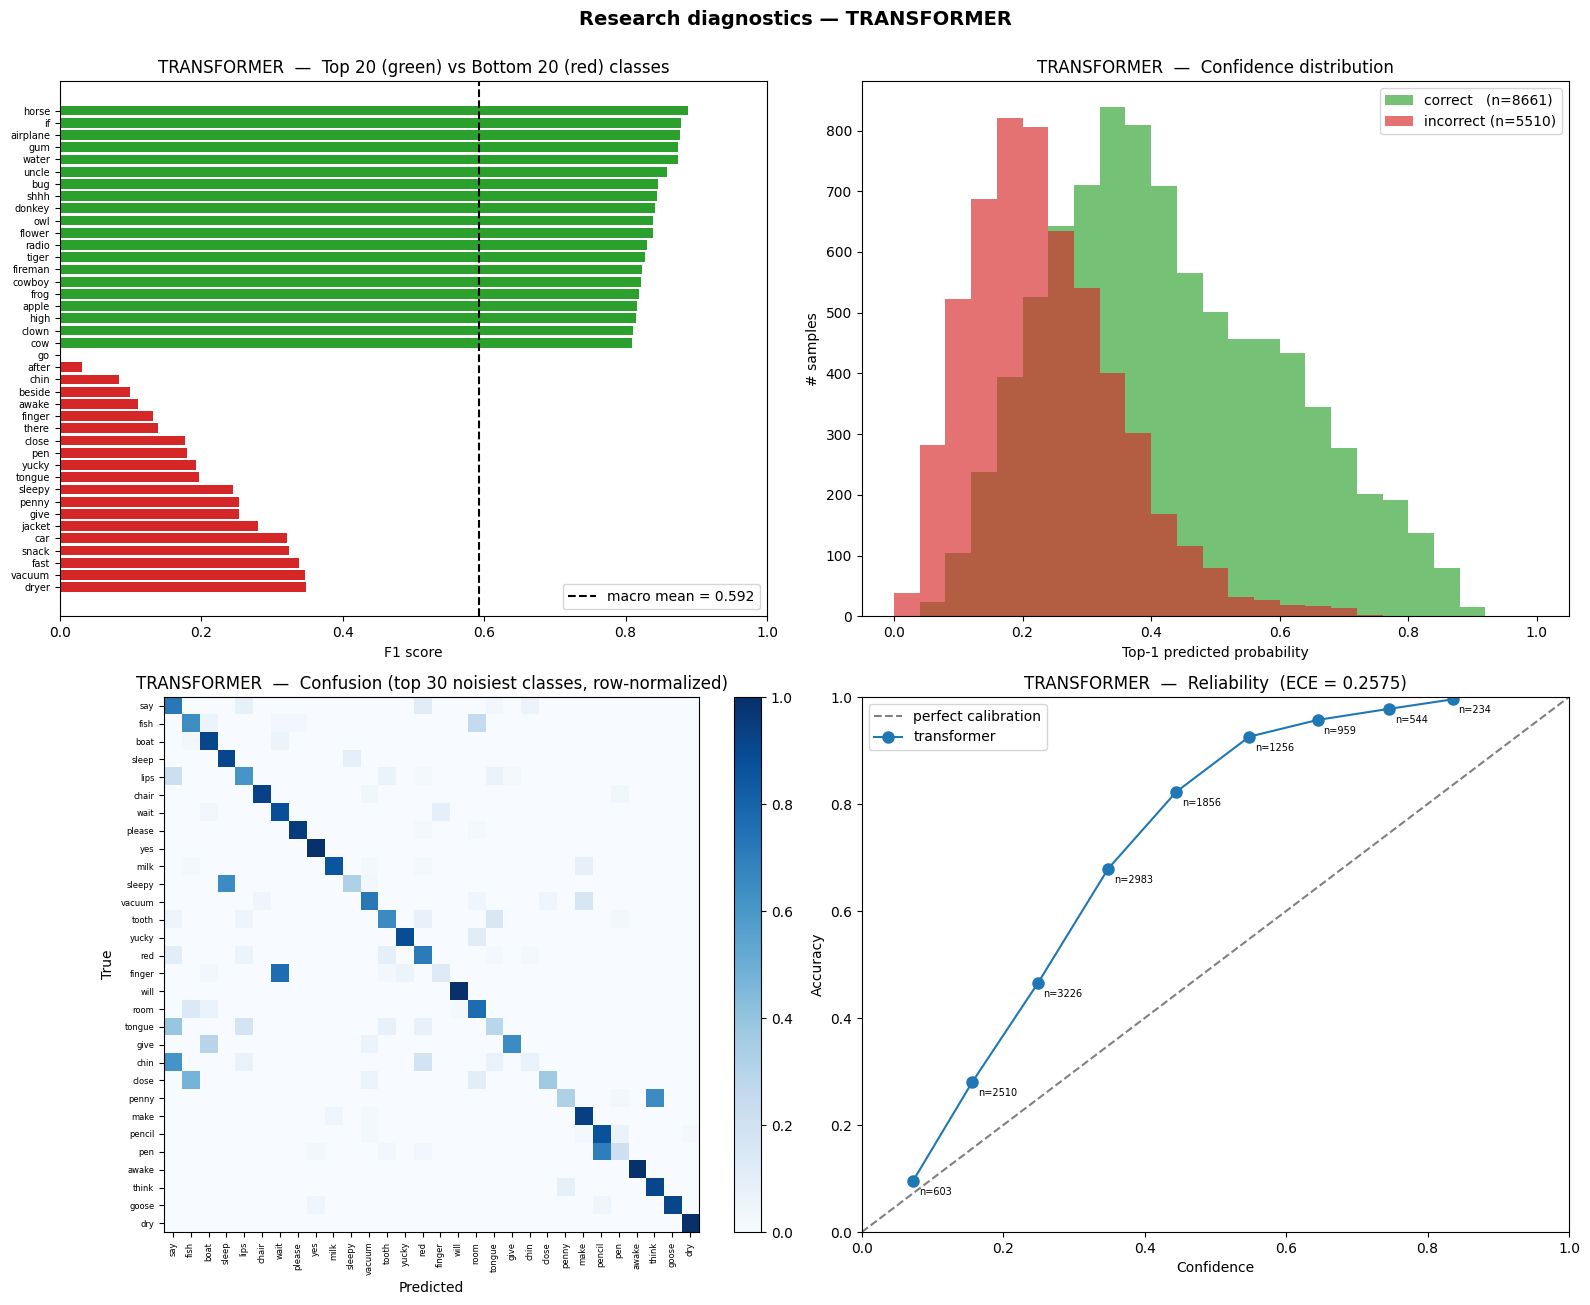

✅ Saved → sign_language_detection\Logs\transformer_research_plots.png


In [22]:
# Transformer research plots
_make_research_plots('transformer', _eval_results, _label_map, LOG_DIR)
